# **Computer Vision libraries in Pytorch**

In [ ]:
# Importing pytorch
import torch
from torch import nn

# Importing torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Importing matplotlib
import matplotlib.pyplot as plt

# Checking versions
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


In [ ]:
# Getting the training and testing data
train_data = datasets.FashionMNIST(root="data",
                                   train=True,
                                   download=True,
                                   transform=ToTensor(),
                                   target_transform=None
)

test_data = datasets.FashionMNIST(root="data",
                                  train=False,
                                  download=True,
                                  transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]


In [ ]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

# **Input and Output shapes**

In [ ]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [ ]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [ ]:
# Classes
classes = train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

# **Visualizing the data**

Shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

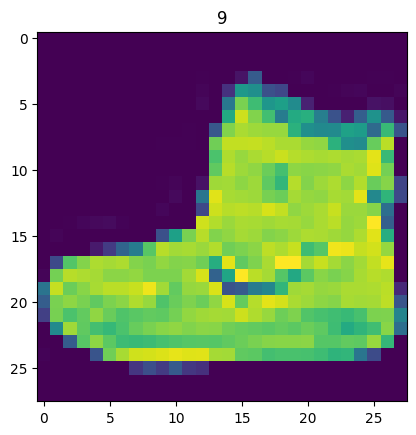

In [ ]:
# Visualizing the data
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

Text(0.5, 1.0, 'Ankle boot')

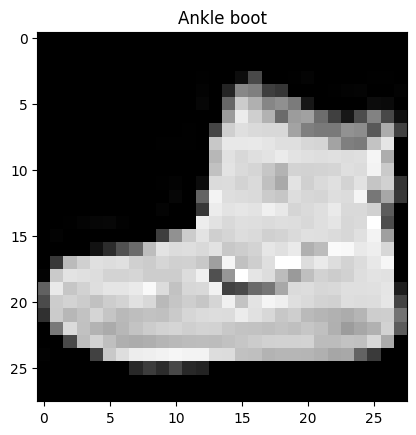

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(classes[label])

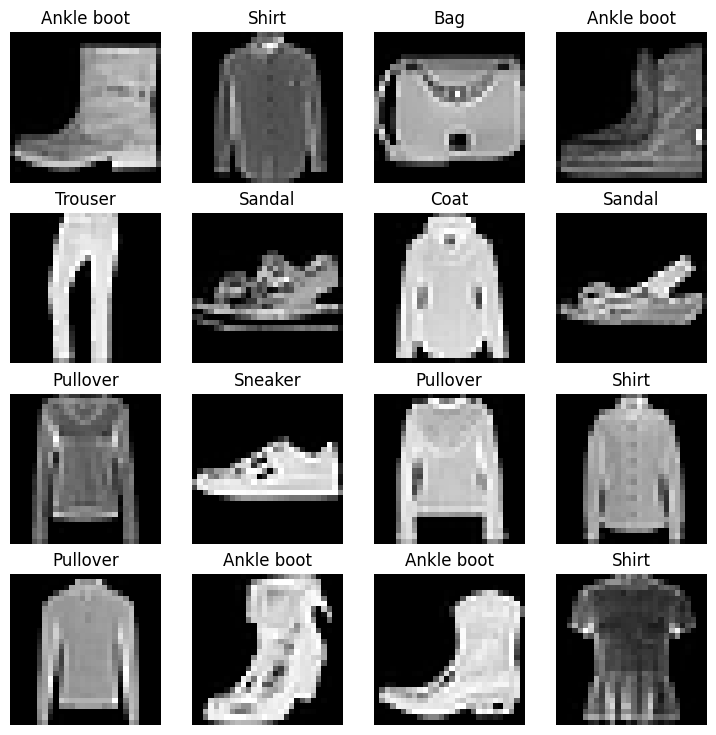

In [ ]:
# Plot random images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols + 1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(classes[label])
  plt.axis(False)

# **Using the dataloader**

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

print(f"Dataloaders: {train_dataloader}, {test_dataloader}")
print(f"Length of Train dataloader: {len(train_dataloader)}, Batch size: {BATCH_SIZE}")
print(f"Length of Test dataloader: {len(test_dataloader)}, Batch size: {BATCH_SIZE}")

Dataloaders: <torch.utils.data.dataloader.DataLoader object at 0x7b21b1916b40>, <torch.utils.data.dataloader.DataLoader object at 0x7b21b25078c0>
Length of Train dataloader: 1875, Batch size: 32
Length of Test dataloader: 313, Batch size: 32


In [ ]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch, train_features_batch.shape, train_labels_batch, train_labels_batch.shape

(tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0157, 0.0000, 0.0039],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000

Image size: torch.Size([1, 28, 28])
Label: 6, Label size: torch.Size([])


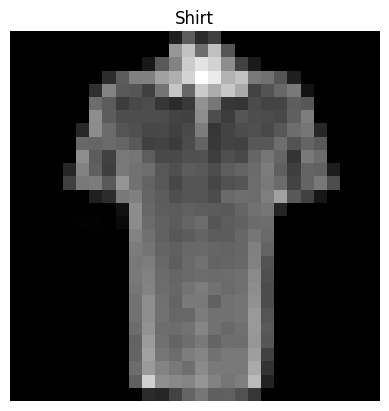

In [ ]:
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(classes[label])
plt.axis("Off")
print(f"Image size: {img.shape}")
print(f"Label: {label}, Label size: {label.shape}")

# **Building the model**

In [ ]:
# Device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# Create a flatten layer
flatten_layer = nn.Flatten()

x = train_features_batch[0]

output = flatten_layer(x)

print(f"X: {x}, Shape: {x.shape}")
print(f"Output: {output}, Shape: {output.shape}")

X: tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0078, 0.0078, 0.0000,
          0.0000, 0.0039, 0.0078, 0.0000, 0.0000, 0.00

In [ ]:
# Building the model
class FashionMNISTModel(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()

    self.layers_stack = nn.Sequential(
        nn.Flatten(), # neural networks like inputs in vector form
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layers_stack(x)

In [ ]:
# Instantiating the model
torch.manual_seed(42)

model_0 = FashionMNISTModel(input_shape=784,
                            hidden_units=10,
                            output_shape=len(classes)).to(device)
model_0, model_0.parameters(), next(model_0.parameters()).device

(FashionMNISTModel(
   (layers_stack): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=784, out_features=10, bias=True)
     (2): Linear(in_features=10, out_features=10, bias=True)
   )
 ),
 <generator object Module.parameters at 0x7b21b15209e0>,
 device(type='cpu'))

# **Loss function and optimizer**

In [ ]:
# Importing helper_functions.py
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Download helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

Download helper_functions.py


In [ ]:
# Loss function and optimizer
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [ ]:
# Timing the training and testing
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device=None):
  total_time = end - start
  print(f"Train time on {device}, {total_time:.3f} seconds")
  return total_time

In [ ]:
# Testing the timing function
start_time = timer()
# Code here
end_time = timer()
print_train_time(start_time, end_time, device="cpu")

Train time on cpu, 0.000 seconds


7.390499996517974e-05

# **Training and testing**

In [ ]:
# Training and testing
from tqdm.auto import tqdm

torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n--------")

  train_loss = 0
  for batch, (X,y) in enumerate(train_dataloader):
    model_0.train()

    y_preds = model_0(X)

    loss = loss_fn(y_preds, y)

    train_loss += loss

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  if batch%400 == 0:
    print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples")

  train_loss /= len(train_dataloader)

  # Testing the model
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X,y in test_dataloader:
      test_preds = model_0(X)

      test_loss += loss_fn(test_preds, y)

      test_acc += accuracy_fn(y_true=y, y_pred=test_preds.argmax(dim=1))

    test_loss /= len(test_dataloader)

    test_acc /= len(test_dataloader)

  print(f"\nTrain loss: {train_loss:.5f}, Test loss: {test_loss:.5f}, Test accuracy: {test_acc:.2f}%\n")

train_time_end_on_cpu = timer()
train_time_model_0 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------

Train loss: 0.59039, Test loss: 0.50954, Test accuracy: 82.04%

Epoch: 1
--------

Train loss: 0.47633, Test loss: 0.47989, Test accuracy: 83.20%

Epoch: 2
--------

Train loss: 0.45503, Test loss: 0.47664, Test accuracy: 83.43%

Train time on cpu, 30.622 seconds


# **Making predictions on the trained model_0**

In [ ]:
# Making predictions on the trained model_0
torch.manual_seed(42)

def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn):
  loss, acc = 0, 0

  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device)

      y_preds = model(X)

      loss += loss_fn(y_preds, y)
      acc += accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

model_0_results = eval_model(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

# **Improving the model**

In [ ]:
# Device agnostic code
import torch
from torch import nn

device  = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# Building the model_1
class FashionMNISTModel1(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()

    self.layers_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )

  def forward(self, x: torch.Tensor):
    return self.layers_stack(x)

In [ ]:
# Instantiating the model
torch.manual_seed(42)
model_1 = FashionMNISTModel1(input_shape=784, hidden_units=8, output_shape=len(classes)).to(device)
model_1, next(model_1.parameters()).device

(FashionMNISTModel1(
   (layers_stack): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=784, out_features=8, bias=True)
     (2): ReLU()
     (3): Linear(in_features=8, out_features=10, bias=True)
     (4): ReLU()
   )
 ),
 device(type='cpu'))

# **Loss function and optimizer**

In [ ]:
# Loss function and optimizer
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

# **Functionizing training and testing loops**

In [ ]:
# Functionizing training and testing loops
def train_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer,
               accuracy_fn, device: torch.device=device):
  train_loss, train_acc = 0, 0
  model.to(device)
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    y_preds = model(X)

    loss = loss_fn(y_preds, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f}, Train accuracy: {train_acc:.2f}%")

def test_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module, accuracy_fn,
              device: torch.device=device):
  test_loss, test_acc = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      test_preds = model(X)
      test_loss += loss_fn(test_preds, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_preds.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f}, Test accuracy: {test_acc:.2f}%")

# **Training and testing the model**

In [ ]:
# Training and testing the model
torch.manual_seed(42)

from timeit import default_timer as timer

train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n--------")
  train_step(model=model_1, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)

  test_step(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)

train_time_end_on_cpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------
Train loss: 0.91913, Train accuracy: 66.24%


KeyboardInterrupt: 

In [ ]:
model_0_results

In [ ]:
train_time_model_0

# **Evaluating the model**

In [ ]:
# Evaluating the model
torch.manual_seed(42)
model_1_results = eval_model(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_1_results

# **Building a Convolutional Neural Network(CNN)**

In [ ]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

In [ ]:
# Building a CNN
class FashionMNISTModel2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
                  kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                  kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                  kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                  kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )

  def forward(self, x):
    x = self.block_1(x)
    # print(f"Output shape of block_1: {x.shape}")
    x = self.block_2(x)
    # print(f"Output shape of block_2: {x.shape}")
    x = self.classifier(x)
    return x

torch.manual_seed(42)
model_2 = FashionMNISTModel2(input_shape=1, hidden_units=10, output_shape=len(classes)).to(device)
model_2

# **Stepping through Conv2d()**

In [ ]:
# Stepping through Conv2d()
torch.manual_seed(42)

images = torch.rand(size=(32, 3, 64, 64))
test_image = images[0]
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")
print(f"Single image pixel values:\n{test_image}")

In [ ]:
torch.manual_seed(42)

conv2d = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=(5, 5), stride=2, padding=0)

conv2d(test_image)

In [ ]:
test_image.unsqueeze(dim=0).shape

In [ ]:
conv2d(test_image.unsqueeze(dim=0)).shape

In [ ]:
conv2d.state_dict()

In [ ]:
# Checking the shape of weight and bias of conv2d
print(f"conv2d weight shape: {conv2d.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"conv2d bias shape: {conv2d.bias.shape} -> [out_channels=10]")

# **Trick to find the input and output shapes**

In [ ]:
rand_image_tensor = torch.randn(size=(1, 28, 28))
rand_image_tensor

In [ ]:
test_shape = model_2(rand_image_tensor.unsqueeze(dim=0).to(device))
test_shape.shape

# Seeing the Pooling layer

In [ ]:
# Seeing the pooling layer
print(f"Test image original shape: {test_image.shape}")
print(f"Test image unsqueeze shape: {test_image.unsqueeze(dim=0).shape}")

test_image_conv2d = conv2d(test_image.unsqueeze(dim=0))
print(f"Test image through conv2d shape: {test_image_conv2d.shape}")

maxpool = nn.MaxPool2d(kernel_size=2)

test_image_maxpool = maxpool(test_image.unsqueeze(dim=0))
print(f"Test image through maxpool shape: {test_image_maxpool.shape}")

test_image_conv2d_maxpool = maxpool(test_image_conv2d)
print(f"Test image through maxpool after conv2d: {test_image_conv2d_maxpool.shape}")

# **Loss function and optimizer**

In [ ]:
# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

# **Training and testing model_2**

In [ ]:
# Training and testing model_2
from timeit import default_timer as timer
torch.manual_seed(42)

epochs = 3

train_time_start_model_2 = timer()

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")

  train_step(model=model_2, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn, device=device)

  test_step(model=model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)

train_time_end_model_2 = timer()
total_train_time = print_train_time(start=train_time_start_model_2, end=train_time_end_model_2, device=device)


In [ ]:
model_2_results = eval_model(model=model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_2_results

In [ ]:
model_0_results

# **Compare model results and training time**

In [ ]:
# Compare model results and training time
import pandas as pd

compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                                model_2_results])
compare_results

In [ ]:
# Plotting Performance-Speed tradeoff
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

# **Making predictions with trained model_2**

In [ ]:
# Making predictions with trained model_2
def make_predictions(model: torch.nn.Module, data: list, device: torch.device=device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)

      pred_logits = model(sample)

      pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)

      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs) # Converts to tensor and adds extra dimension

In [ ]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({classes[test_labels[0]]})")

In [ ]:
# Making predictions with trained model_2
pred_probs = make_predictions(model=model_2, data=test_samples)
pred_probs[:2]

In [ ]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

In [ ]:
test_labels, pred_classes

# **Visualizing the predictions**

In [ ]:
# Visualizing the predictions
plt.figure(figsize=(9, 9))
n_rows = 3
n_cols = 3
for i, sample in enumerate(test_samples):
  plt.subplot(n_rows, n_cols, i+1)

  plt.imshow(sample.squeeze(), cmap="gray")

  pred_label = classes[pred_classes[i]]

  truth_label = classes[test_labels[i]]

  title_text = f"Pred: {pred_label}, Truth: {truth_label}"

  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c="g")
  else:
    plt.title(title_text, fontsize=10, c="r")
  plt.axis(False)

# **Plotting the confusion matrix**

In [ ]:
# Making predictions on all test data
from tqdm.auto import tqdm

y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    y_logits = model_2(X)

    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

In [ ]:
import mlxtend
print(mlxtend.__version__)

In [ ]:
# Importing torchmetrics and mlxtend
import torchmetrics

In [ ]:
# Plotting the confusion matrix
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(classes), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(), class_names=classes, figsize=(10, 7))

# **Saving and Loading the model**

In [ ]:
# Saving the model
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "Pytorch_03_Computer_Vision_model_CNN.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)

In [ ]:
# Loading the model
loaded_model_2 = FashionMNISTModel2(input_shape=1, hidden_units=10, output_shape=len(classes))

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_2.to(device)

loaded_model_2.state_dict()

In [ ]:
# Evalutating the loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(model=loaded_model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)

loaded_model_2_results

In [ ]:
model_2_results

In [ ]:
# Checking if the results are close to each other
torch.isclose(torch.tensor(model_2_results["model_loss"]), torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-08, rtol=0.0001)

# **Exercises**

In [ ]:
# Device agnostic code
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# Loading the MNIST dataset
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.MNIST(root="data", train=True, download=True, transform=ToTensor(), target_transform=None)

test_data = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 108MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 49.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 146MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.61MB/s]


In [ ]:
train_data[0]
image, label = train_data[0]
image.shape, label

(torch.Size([1, 28, 28]), 5)

In [ ]:
classes = train_data.classes
classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

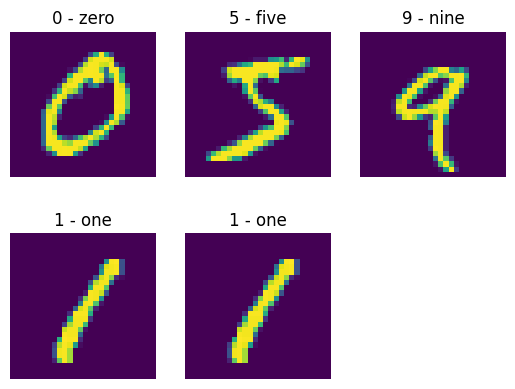

In [ ]:
# Visualizing 5 different samples
import random
random.seed(42)
import matplotlib.pyplot as plt
n_rows, n_cols = 2, 3
n_samples = 5
for i in range(n_samples):
  image, label = train_data[random.randint(0, len(classes)-1)]
  plt.subplot(n_rows, n_cols, i+1)
  plt.imshow(image.squeeze())
  plt.title(train_data.classes[label])
  plt.axis(False)

In [ ]:
# Turning data into dataloaders
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)

test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataloaders: {train_dataloader}, {test_dataloader}")
print(f"Length of Train dataloader: {len(train_dataloader)}, batch size: {BATCH_SIZE}")
print(f"Lenght of Test dataloader: {len(test_dataloader)}, batch_size: {BATCH_SIZE}")

Dataloaders: <torch.utils.data.dataloader.DataLoader object at 0x7ac4d1e1b0b0>, <torch.utils.data.dataloader.DataLoader object at 0x7ac4d1ec2b70>
Length of Train dataloader: 1875, batch size: 32
Lenght of Test dataloader: 313, batch_size: 32


In [ ]:
# Visualizing what's inside the dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image shape: torch.Size([1, 28, 28])
Label: 6, Label shape: torch.Size([])


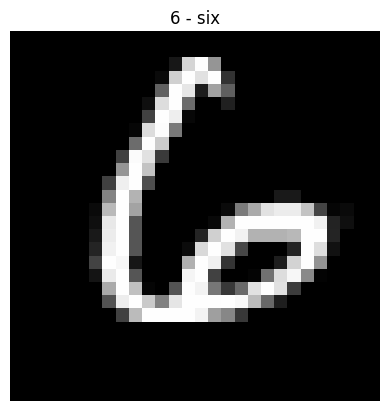

In [ ]:
torch.manual_seed(42)

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
image, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(classes[label])
plt.axis(False)
print(f"Image shape: {image.shape}")
print(f"Label: {label}, Label shape: {label.shape}")

In [ ]:
# Building the model
class MNISTModel(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()

    self.layer_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.layer_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.layer_block_1(x)
    x = self.layer_block_2(x)
    x = self.classifier(x)
    return x

torch.manual_seed(42)
model_0 = MNISTModel(input_shape=1, hidden_units=10, output_shape=len(classes)).to(device)
model_0

MNISTModel(
  (layer_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
# Importing helper_functions.py for accuracy function
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Download helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

Download helper_functions.py


In [ ]:
# Setting up the loss function and optimizer
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [ ]:
# Function to print total training and testing time
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device=None):
  total_time = end - start
  print(f"Total time on {device}: {total_time:.3f}")
  return total_time

In [ ]:
# Functionizing the training and testing loops
def train_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy_fn, device: torch.device=device):
  train_loss, train_acc = 0, 0
  model.to(device)
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    y_preds = model(X)

    loss = loss_fn(y_preds, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  print(f"Train loss: {train_loss:.5f}, Train accuracy: {train_acc:.2f}%")

def test_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device: torch.device=device):
  test_loss, test_acc = 0, 0
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for X,y in data_loader:
      X, y = X.to(device), y.to(device)

      test_preds = model(X)

      test_loss += loss_fn(test_preds, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_preds.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f}, Test accuracy: {test_acc:.2f}%")

In [ ]:
# Training and testing
from tqdm.auto import tqdm

torch.manual_seed(42)

train_time_start_on_device = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")

  train_step(model=model_0, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn, device=device)
  test_step(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)

train_time_end_on_device = timer()
total_train_time = print_train_time(start=train_time_start_on_device, end=train_time_end_on_device, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.33561, Train accuracy: 88.74%
Test loss: 0.07362, Test accuracy: 97.71%
Epoch: 1
-------
Train loss: 0.08217, Train accuracy: 97.44%
Test loss: 0.06596, Test accuracy: 97.95%
Epoch: 2
-------
Train loss: 0.06436, Train accuracy: 97.97%
Test loss: 0.05947, Test accuracy: 98.04%
Total time on cpu: 156.072


In [ ]:
# Function to evaluate the model
def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device: torch.device=device):
  loss, acc = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      y_preds = model(X)

      loss += loss_fn(y_preds, y)
      acc +=  accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
          "model_loss": loss,
          "model_acc": acc}

In [ ]:
# Evaluating model_0 results
model_0_results = eval_model(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)
model_0_results

{'model_name': 'MNISTModel',
 'model_loss': tensor(0.0595),
 'model_acc': 98.04313099041534}

In [ ]:
# Functionizing making predictions
def make_predictions(model: torch.nn.Module, data: list, device: torch.device=device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)

      pred_logits = model(sample)

      pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)

      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)

In [ ]:
# Generating new data for predictions
import random
random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

print(f"Test sample image shape: {test_samples[0].shape}\n Test sample label: {test_labels[0]}, {classes[test_labels[0]]}")

Test sample image shape: torch.Size([1, 28, 28])
 Test sample label: 2, 2 - two


In [ ]:
# Making predictions on the generated data
pred_probs = make_predictions(model=model_0, data=test_samples, device=device)

pred_probs[:2]

tensor([[9.5611e-11, 5.2553e-07, 1.0000e+00, 1.3429e-07, 2.3216e-14, 1.6182e-15,
         1.1093e-13, 6.9319e-09, 1.7391e-06, 1.2477e-10],
        [1.3504e-07, 9.9834e-01, 1.5989e-06, 5.4371e-08, 6.9274e-06, 7.8727e-04,
         2.2412e-04, 2.4924e-07, 6.1812e-04, 1.8624e-05]])

In [ ]:
# Converting prediction probabiltites into prediction labels
pred_labels = pred_probs.argmax(dim=1)

pred_labels

tensor([2, 1, 2, 4, 6, 6, 4, 9, 1])

In [ ]:
pred_labels, test_labels

(tensor([2, 1, 2, 4, 6, 6, 4, 9, 1]), [2, 1, 2, 4, 6, 6, 4, 9, 1])

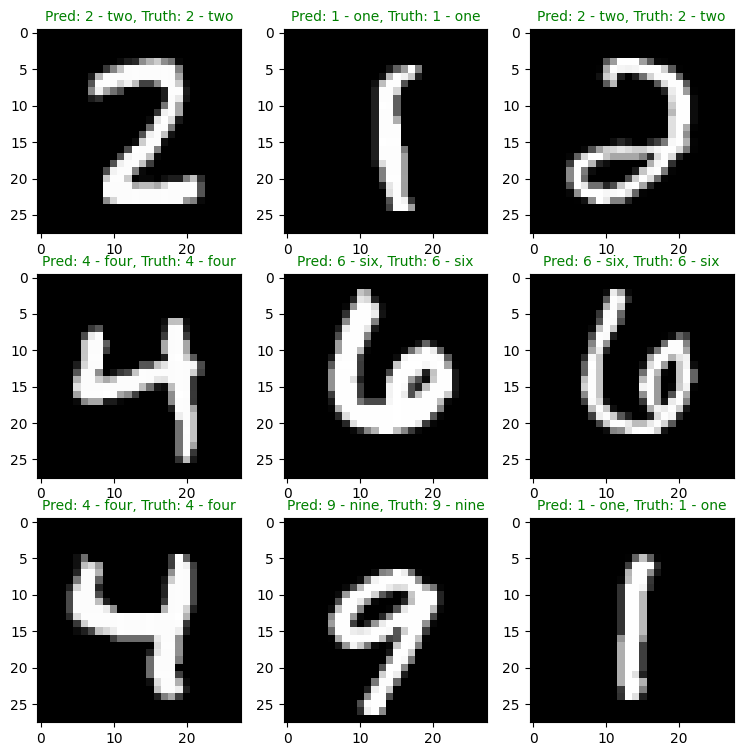

In [ ]:
# Visualizing the data
plt.figure(figsize=(9, 9))

n_rows = 3
n_cols = 3

for i, sample in enumerate(test_samples):
  plt.subplot(n_rows, n_cols, i+1)

  plt.imshow(sample.squeeze(), cmap="gray")

  pred_label = classes[pred_labels[i]]

  truth_label = classes[test_labels[i]]

  title_text = f"Pred: {pred_label}, Truth: {truth_label}"

  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c="g")
  else:
    plt.title(title_text, fontsize=10, c="r")

In [ ]:
!pip install torchmetrics

In [ ]:
# Testing the data on test_data
from tqdm.auto import tqdm

y_preds = []
model_0.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    X, y = X.to(device), y.to(device)
    y_logits = model_0(X)

    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

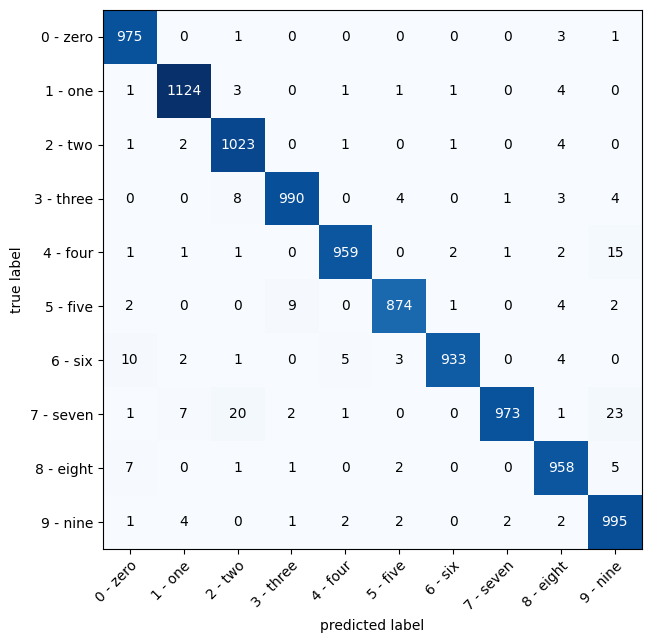

In [ ]:
# Plotting the confusion matrix
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(classes), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(), class_names=classes, figsize=(10, 7))

In [ ]:
# Experiment
random_tensor = torch.rand(size=(1, 3, 64, 64))

conv2d_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=1, padding=1)

result = conv2d_layer(random_tensor)
result.shape

torch.Size([1, 10, 64, 64])

# Exercise model 1

In [ ]:
# Device Agnostic code
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# Getting the FashionMNIST dataset
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

train_data = datasets.FashionMNIST(root="data", train=True, download=True, transform=ToTensor(), target_transform=None)

test_data = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.90MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 59.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]


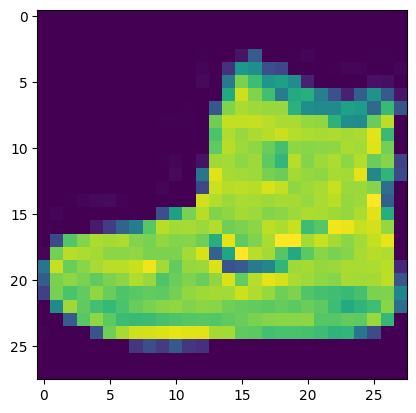

In [ ]:
image, label = train_data[0]
plt.imshow(image.squeeze(dim=0))

In [ ]:
num_classes = train_data.classes
num_classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

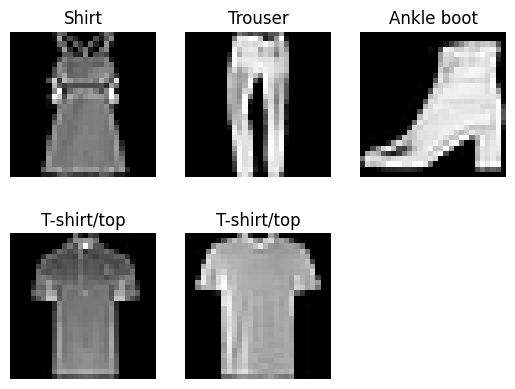

In [ ]:
# Visualizing dataset
import random
random.seed(42)

n_rows, n_cols = 2, 3
n_samples = 5

for i in range(5):
  random_idx = random.randint(0, len(train_data)-1)
  image, label = train_data[random_idx]
  plt.subplot(n_rows, n_cols, i+1)
  plt.imshow(image.squeeze(dim=0), cmap="gray")
  plt.title(num_classes[label])
  plt.axis(False)

In [ ]:
# Building the model
class FashionMNISTModel(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()

    self.layers_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(num_features=hidden_units),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(num_features=hidden_units),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(p=0.25)
    )

    self.layers_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(num_features=hidden_units),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(num_features=hidden_units),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(p=0.25)
    )

    self.classifier_layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=hidden_units),
        nn.ReLU(),
        nn.BatchNorm1d(num_features=hidden_units),
        nn.Dropout(p=0.25),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.layers_block_1(x)
    x = self.layers_block_2(x)
    x = self.classifier_layer(x)
    return x

model_1 = FashionMNISTModel(input_shape=1, hidden_units=10, output_shape=len(num_classes))
model_1

FashionMNISTModel(
  (layers_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (layers_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(ker

In [ ]:
# Turning data into dataloaders
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)

test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7b600c3c95b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7b5fc8ecd370>)

In [ ]:
# Importing accuracy function
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists.")
else:
  print("Download helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

Download helper_functions.py


In [ ]:
# Loss function and optimizer
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [ ]:
# Trianing and testing functions
def train_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer, accuracy_fn, device: torch.device=device):
  train_loss, train_acc = 0, 0
  model.to(device)
  #model.train()
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    y_logits = model(X)

    y_preds = torch.softmax(y_logits, dim=1)

    loss = loss_fn(y_preds, y)

    train_loss += loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_preds.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  print(f"Train loss: {train_loss:.5f}, Train acc: {train_acc:.2f}%")

def test_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module, accuracy_fn, device: torch.device=device):
  test_loss, test_acc = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      test_preds = model(X)

      test_loss += loss_fn(test_preds, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_preds.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

  print(f"Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

In [ ]:
# Train time funcitons
def print_train_time(start: float, end: float, device: torch.device=None):
  total_time = end - start
  print(f"Total time: {total_time:.3f}")
  return total_time

In [ ]:
# Training and testing the model
from tqdm.auto import tqdm
from timeit import default_timer as timer

torch.manual_seed(42)

train_time_start_on_device = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_step(model=model_1, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer,
             accuracy_fn=accuracy_fn, device=device)

  test_step(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)

train_time_end_on_device = timer()
total_time = print_train_time(start=train_time_start_on_device, end=train_time_end_on_device, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 1.82303, Train acc: 67.19%
Test loss: 1.02017, Test acc: 78.50%
Epoch: 1
-------
Train loss: 1.64324, Train acc: 81.80%
Test loss: 1.87534, Test acc: 82.80%
Epoch: 2
-------
Train loss: 1.63448, Train acc: 82.62%
Test loss: 2.35238, Test acc: 82.88%
Total time: 195.024


In [ ]:
# Evaluating model
def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device: torch.device=device):
  loss, acc = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      pred_logits = model(X)

      loss += loss_fn(pred_logits, y)
      acc += accuracy_fn(y_true=y, y_pred=pred_logits.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
          "loss": loss,
          "accuracy": acc}

In [ ]:
# Making predictions
def make_predictions(model: torch.nn.Module, data: list, device: torch.device=device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)

      pred_logits = model(sample)

      pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)

      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)

In [ ]:
# Generating data for predictions
import random

random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0], test_labels

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [ ]:
# Results of model
model_1_results = eval_model(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn, device=device)
model_1_results

{'model_name': 'FashionMNISTModel',
 'loss': tensor(2.3524),
 'accuracy': 82.87739616613419}

In [ ]:
# Making predictions
preds = make_predictions(model=model_1, data=test_samples, device=device)

preds[:2]

tensor([[4.5555e-25, 1.9062e-24, 7.2544e-20, 1.1048e-30, 7.0203e-37, 1.0000e+00,
         2.4156e-23, 3.5786e-17, 1.6486e-14, 1.7247e-14],
        [5.2294e-15, 9.9999e-01, 4.4022e-15, 9.6635e-06, 1.9754e-10, 6.0468e-14,
         8.8747e-14, 4.6318e-11, 2.5893e-13, 7.8916e-14]])

In [ ]:
pred_labels = preds.argmax(dim=1)
pred_labels

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [ ]:
pred_labels, test_labels

(tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]), [5, 1, 7, 4, 3, 0, 4, 7, 1])

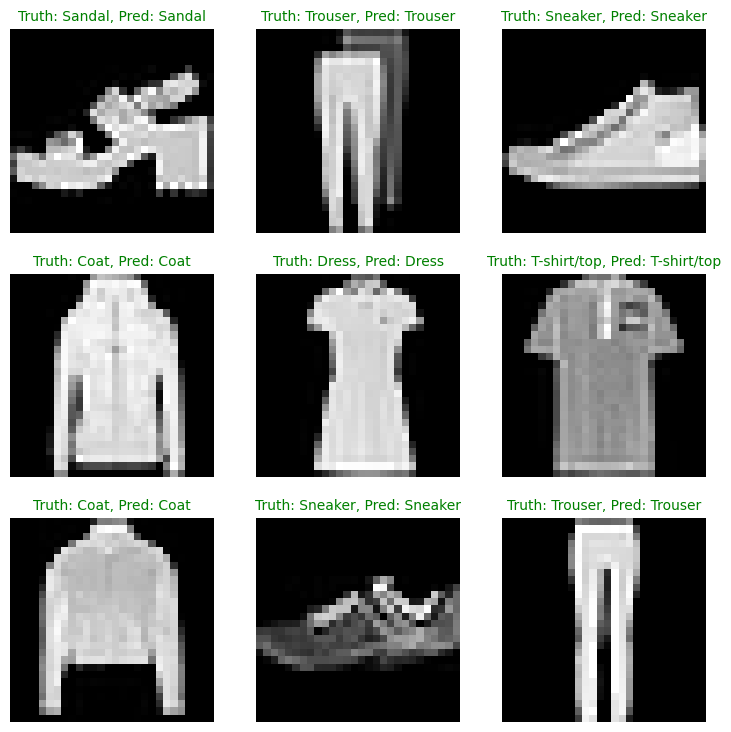

In [ ]:
# Visualizing the data
plt.figure(figsize=(9, 9))

n_rows = 3
n_cols = 3

for i, sample in enumerate(test_samples):
  plt.subplot(n_rows, n_cols, i+1)

  plt.imshow(sample.squeeze(), cmap="gray")

  plt.axis("Off")

  pred_text = num_classes[pred_labels[i]]

  truth_text = num_classes[test_labels[i]]

  title_text = f"Truth: {truth_text}, Pred: {pred_text}"

  if pred_labels[i] == test_labels[i]:
    plt.title(title_text, fontsize=10, c='g')
  else:
    plt.title(title_text, fontsize=10, c='r')

In [ ]:
!pip install torchmetrics

In [ ]:
# Making predictions on test data
from tqdm.auto import tqdm

y_preds = []
model_1.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    X, y = X.to(device), y.to(device)

    y_logit = model_1(X)

    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)

    y_preds.append(y_pred.cpu())

y_preds_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

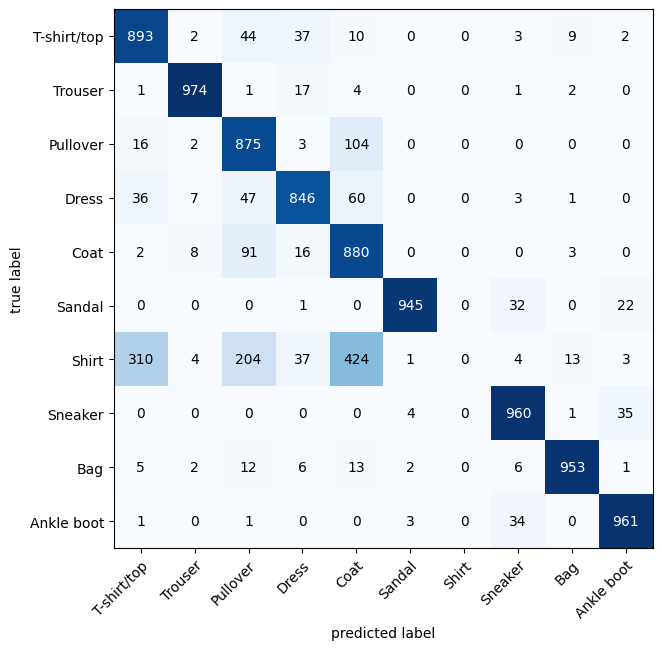

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(num_classes), task='multiclass')
confmat_tensor = confmat(preds=y_preds_tensor, target=test_data.targets)

fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(), class_names=num_classes, figsize=(10, 7))